РЕЗУЛЬТАТЫ МОДЕЛЕЙ
            Model    MAE    MSE
Linear Regression 0.5332 0.5559
    Random Forest 0.3274 0.2552
Gradient Boosting 0.3717 0.2940


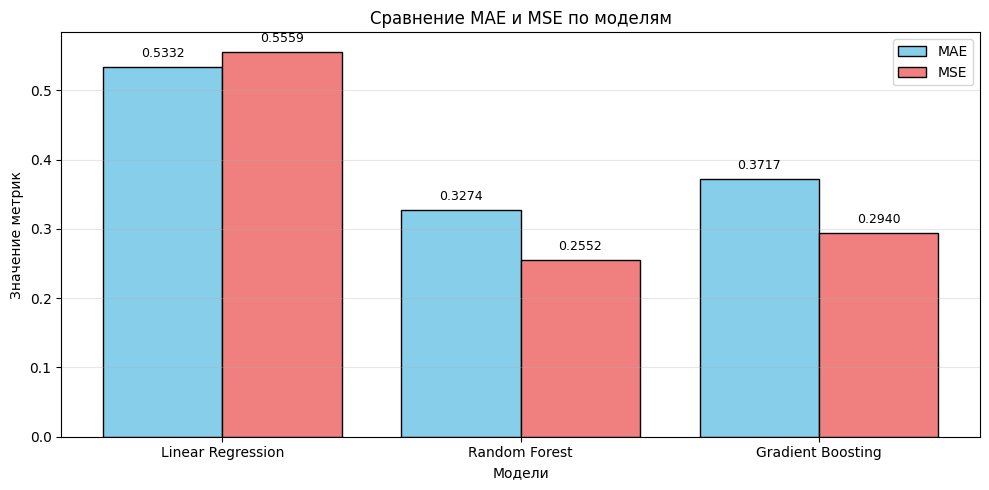

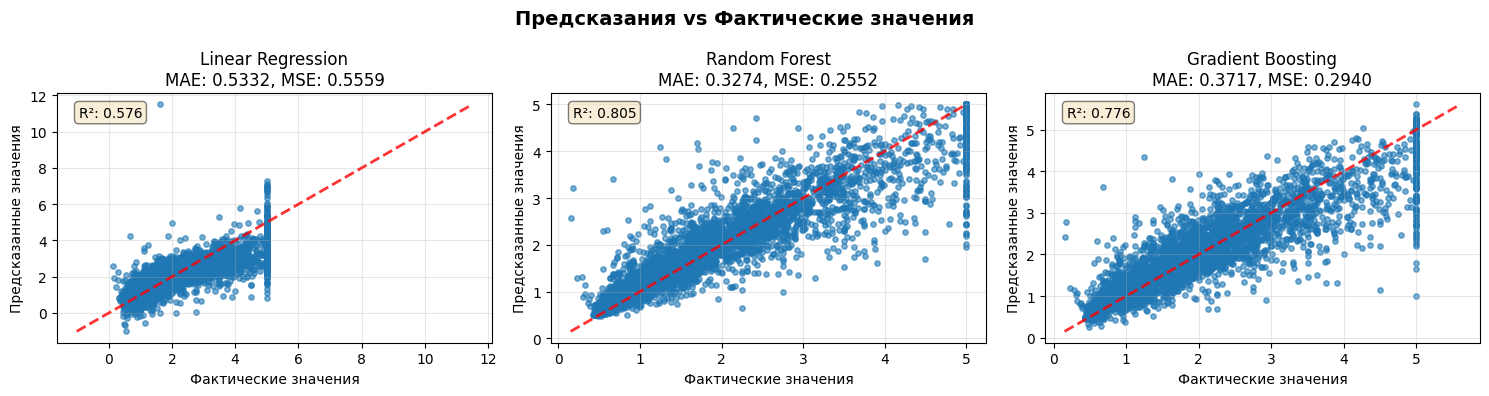

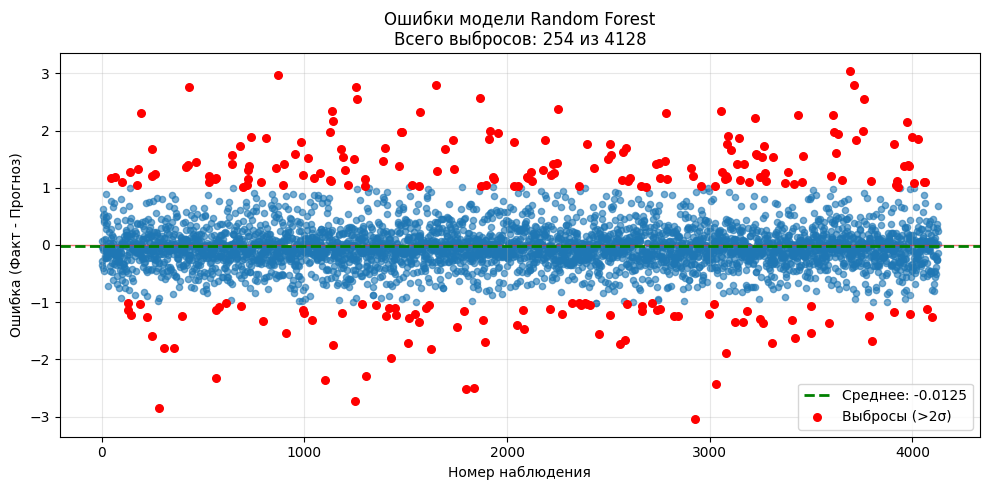

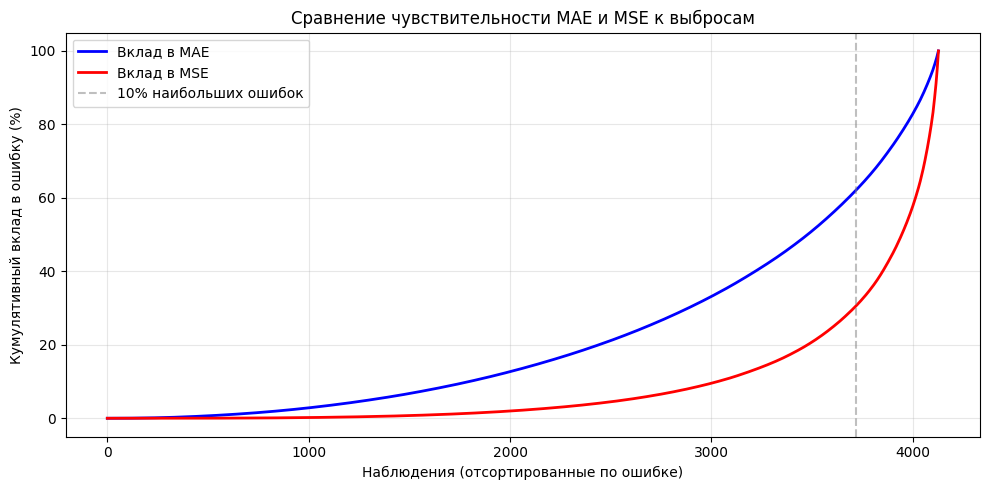


КРАТКАЯ ИНТЕРПРЕТАЦИЯ
MAE (Mean Absolute Error): Средняя абсолютная ошибка
MSE (Mean Squared Error): Средняя квадратичная ошибка

MSE сильнее штрафует за большие ошибки (выбросы)
MAE менее чувствительна к выбросам

Лучшая модель по MAE: Random Forest
Лучшая модель по MSE: Random Forest


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Загрузка данных
data = fetch_california_housing()
X, y = data.data, data.target

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Создание и обучение моделей
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Хранение результатов
results = []

# Обучение и предсказание
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # Вычисление метрик
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    results.append({
        'Model': name,
        'MAE': round(mae, 4),
        'MSE': round(mse, 4)
    })

# Таблица результатов
print("="*60)
print("РЕЗУЛЬТАТЫ МОДЕЛЕЙ")
print("="*60)
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
print("="*60)

# ВИЗУАЛИЗАЦИЯ 1: Сравнение метрик
plt.figure(figsize=(10, 5))
x = np.arange(len(models))

mae_values = [r['MAE'] for r in results]
mse_values = [r['MSE'] for r in results]

plt.bar(x - 0.2, mae_values, 0.4, label='MAE', color='skyblue', edgecolor='black')
plt.bar(x + 0.2, mse_values, 0.4, label='MSE', color='lightcoral', edgecolor='black')

plt.xlabel('Модели')
plt.ylabel('Значение метрик')
plt.title('Сравнение MAE и MSE по моделям')
plt.xticks(x, list(models.keys()))
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# Добавление значений на столбцы
for i, v in enumerate(mae_values):
    plt.text(i - 0.2, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontsize=9)
for i, v in enumerate(mse_values):
    plt.text(i + 0.2, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# ВИЗУАЛИЗАЦИЯ 2: Предсказания vs Фактические значения
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Предсказания vs Фактические значения', fontsize=14, fontweight='bold')

for idx, (name, model) in enumerate(models.items()):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    ax = axes[idx]
    ax.scatter(y_test, y_pred, alpha=0.6, s=15)

    # Линия идеальных предсказаний
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', alpha=0.8, linewidth=2)

    # Вычисление R² для аннотации
    from sklearn.metrics import r2_score
    r2 = r2_score(y_test, y_pred)

    ax.set_xlabel('Фактические значения')
    ax.set_ylabel('Предсказанные значения')
    ax.set_title(f'{name}\nMAE: {mae_values[idx]:.4f}, MSE: {mse_values[idx]:.4f}')
    ax.text(0.05, 0.95, f'R²: {r2:.3f}', transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ВИЗУАЛИЗАЦИЯ 3: График ошибок
plt.figure(figsize=(10, 5))

# Берем лучшую модель для демонстрации ошибок
best_model_idx = np.argmin(mae_values)
best_model_name = list(models.keys())[best_model_idx]
best_model = models[best_model_name]
best_model.fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_test_scaled)
errors = y_test - y_pred_best

plt.scatter(range(len(errors)), errors, alpha=0.6, s=20)
plt.axhline(y=0, color='r', linestyle='-', linewidth=1, alpha=0.5)
plt.axhline(y=np.mean(errors), color='g', linestyle='--', linewidth=2,
            label=f'Среднее: {np.mean(errors):.4f}')

# Выделяем выбросы (ошибки > 2 стандартных отклонения)
threshold = 2 * np.std(errors)
outliers = np.abs(errors) > threshold
plt.scatter(np.where(outliers)[0], errors[outliers],
           color='red', s=30, label='Выбросы (>2σ)', zorder=5)

plt.xlabel('Номер наблюдения')
plt.ylabel('Ошибка (Факт - Прогноз)')
plt.title(f'Ошибки модели {best_model_name}\nВсего выбросов: {sum(outliers)} из {len(errors)}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ВИЗУАЛИЗАЦИЯ 4: Сравнение чувствительности MAE и MSE к выбросам
plt.figure(figsize=(10, 5))

# Используем ошибки из лучшей модели
abs_errors = np.abs(errors)
sorted_errors = np.sort(abs_errors)

# Кумулятивные суммы для визуализации влияния
cumulative_mae = np.cumsum(sorted_errors) / np.sum(sorted_errors)
cumulative_mse = np.cumsum(sorted_errors**2) / np.sum(sorted_errors**2)

plt.plot(np.arange(len(sorted_errors)), cumulative_mae * 100,
         label='Вклад в MAE', linewidth=2, color='blue')
plt.plot(np.arange(len(sorted_errors)), cumulative_mse * 100,
         label='Вклад в MSE', linewidth=2, color='red')

# Показываем вклад 10% наибольших ошибок
n_10_percent = int(len(sorted_errors) * 0.1)
plt.axvline(x=len(sorted_errors) - n_10_percent, color='gray',
            linestyle='--', alpha=0.5, label='10% наибольших ошибок')

plt.xlabel('Наблюдения (отсортированные по ошибке)')
plt.ylabel('Кумулятивный вклад в ошибку (%)')
plt.title('Сравнение чувствительности MAE и MSE к выбросам')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Итоговая информация
print("\n" + "="*60)
print("КРАТКАЯ ИНТЕРПРЕТАЦИЯ")
print("="*60)
print("MAE (Mean Absolute Error): Средняя абсолютная ошибка")
print("MSE (Mean Squared Error): Средняя квадратичная ошибка")
print("\nMSE сильнее штрафует за большие ошибки (выбросы)")
print("MAE менее чувствительна к выбросам")
print(f"\nЛучшая модель по MAE: {results_df.loc[results_df['MAE'].idxmin(), 'Model']}")
print(f"Лучшая модель по MSE: {results_df.loc[results_df['MSE'].idxmin(), 'Model']}")